# Analysis of the simulated network for Germany
Simulated 1 day (14.04.2025) with hourly resolution for the whole germany including offshore areas. 

In [ ]:
#Build the network 
#snakemake --cores 6 "resources/germany/networks/base_s_470_elec_.nc" --configfile config/config.germany.yaml

#Solve the network -> for line loads
#snakemake -call solve_elec_networks --configfile config/config.germany.yaml

In [75]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs

In [95]:
#config_name = "germany-test"
#cluster = "20"

config_name = "germany"
cluster = "470"

# Correct path to the network file after adding electricity components
network_path_unsolved = f"pypsa-eur/resources/{config_name}/networks/base_s_{cluster}_elec.nc"
n_unsolved = pypsa.Network(network_path_unsolved)

network_path_solved = f"pypsa-eur/results/{config_name}/networks/base_s_{cluster}_elec_.nc"
#network_path_solved = f"pypsa-eur/results/{config_name}/networks/base_s_{cluster}_elec_.nc"
n = pypsa.Network(network_path_solved)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks


### Plot the base network
Plotting for quick overview about the nodes and lines.

In [96]:
print(f"Network name: {getattr(n, 'name', 'N/A')}")
print(f"Snapshots: {len(n.snapshots)} | Investment periods: {getattr(n, 'investment_periods', [])}")
print(f"Objective available: {'objective' in dir(n)}")

component_counts = pd.Series({
    "buses": len(n.buses),
    "lines": len(n.lines),
    "links": len(n.links),
    "generators": len(n.generators),
    "loads": len(n.loads),
    "storage_units": len(n.storage_units),
    "stores": len(n.stores),
    "transformers": len(n.transformers),
})

print("\nComponent counts:")
display(component_counts.to_frame("count"))

print("\nCarriers per major component:")
for comp_name, comp_df in {
    "generators": n.generators,
    "loads": n.loads,
    "lines": n.lines,
    "links": n.links,
    "storage_units": n.storage_units,
}.items():
    if not comp_df.empty and "carrier" in comp_df.columns:
        print(f"- {comp_name}: {comp_df['carrier'].nunique()} carriers")
    else:
        print(f"- {comp_name}: no carrier column or empty")

Network name: Unnamed Network
Snapshots: 48 | Investment periods: Index([], dtype='object', name='period')
Objective available: True

Component counts:


,count
buses,1410
lines,666
links,1898
generators,2667
loads,470
storage_units,0
stores,940
transformers,0



Carriers per major component:
- generators: 12 carriers
- loads: 1 carriers
- lines: 1 carriers
- links: 5 carriers
- storage_units: no carrier column or empty


In [97]:
# --- Capacity and topology ---
if not n.generators.empty:
    cap_by_carrier = n.generators.groupby("carrier")["p_nom"].sum().sort_values(ascending=False)
    print("Installed generator capacity by carrier [MW]:")
    display(cap_by_carrier.head(20).to_frame("p_nom_MW"))

    cap_by_bus = n.generators.groupby("bus")["p_nom"].sum().sort_values(ascending=False)
    print("\nTop buses by installed generation capacity [MW]:")
    display(cap_by_bus.head(15).to_frame("p_nom_MW"))

if not n.loads.empty and hasattr(n.loads_t, "p_set") and not n.loads_t.p_set.empty:
    annual_load_by_bus = n.loads_t.p_set.sum().sort_values(ascending=False)
    print("\nTop buses by annual load [MWh over snapshots]:")
    display(annual_load_by_bus.head(15).to_frame("load_MWh"))

if not n.lines.empty:
    print("\nLine length statistics [km]:")
    if "length" in n.lines.columns:
        display(n.lines["length"].describe().to_frame("value"))
    else:
        print("No 'length' column in n.lines")

Installed generator capacity by carrier [MW]:


,p_nom_MW
carrier,
onwind,73332.065900
solar,48771.254020
CCGT,30783.128330
coal,20351.945000
lignite,19457.035000
offwind-ac,11163.743000
biomass,8020.001833
OCGT,6112.743723
oil,5684.345986



Top buses by installed generation capacity [MW]:


,p_nom_MW
bus,
DE0 358,6615.661395
DE0 140,4622.186951
DE0 310,4616.836090
DE0 399,4281.689030
DE0 116,3952.658212
DE0 32,3930.192727
DE0 55,3235.673001
DE0 312,3185.559024
DE0 430,3103.332880



Top buses by annual load [MWh over snapshots]:


,load_MWh
name,
DE0 12,57904.691284
DE0 44,55375.284782
DE0 36,39646.555634
DE0 15,35897.630241
DE0 129,33909.847046
DE0 45,33502.680565
DE0 106,30906.525589
DE0 116,28798.556030
DE0 62,26989.405319



Line length statistics [km]:


,value
count,666.000000
mean,25.044439
std,24.795309
min,1.043104
25%,6.739575
50%,15.831136
75%,37.248927
max,206.742555


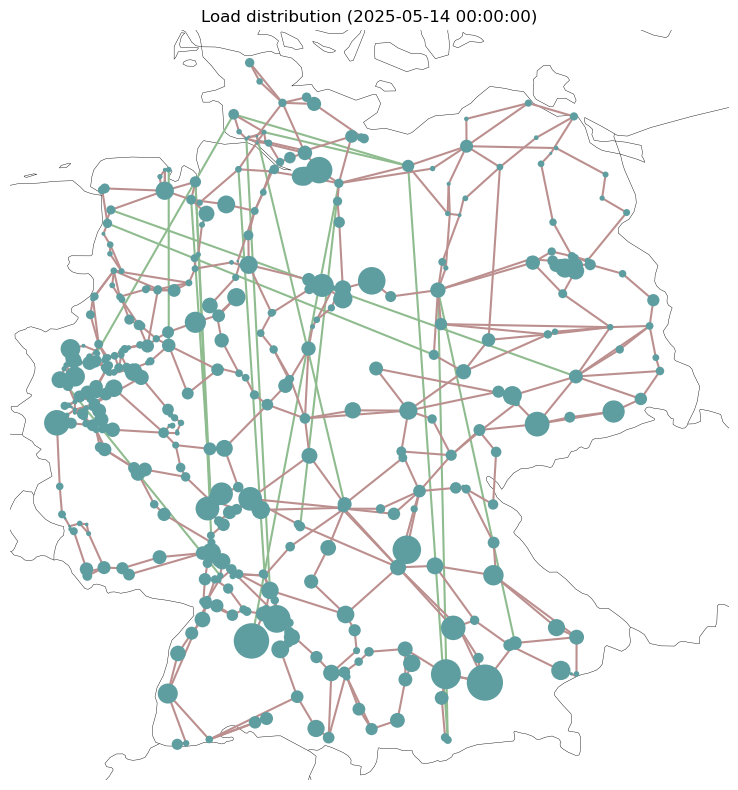

In [98]:
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 8),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

snapshot = n.snapshots[0]
load_distribution = n.loads_t.p_set.loc[snapshot].groupby(n.loads.bus).sum()
carriers = n.generators.groupby("carrier").groups.keys()
print(carriers)
#carriers_colors = 

n.plot(
    bus_sizes=load_distribution/20000,
    #bus_colors=carriers_colors,
    ax=ax,
    geomap=True,
    title=f"Load distribution ({snapshot})",
);

plt.tight_layout()
plt.show()

In [99]:
loads = n.loads_t.p_set.sum()
print(loads)

name
DE0 0      17090.640045
DE0 1      18330.012024
DE0 10      6596.377426
DE0 100    16634.606247
DE0 101     4361.633591
               ...     
DE0 95     24860.914093
DE0 96      6281.260452
DE0 97      1503.442650
DE0 98      2522.287453
DE0 99      8487.977737
Length: 470, dtype: float64


In [100]:
n.generators.groupby("carrier")["p_nom"].sum()

carrier
CCGT          30783.128330
OCGT           6112.743723
biomass        8020.001833
coal          20351.945000
geothermal       26.900000
lignite       19457.035000
offwind-ac    11163.743000
offwind-dc        0.000000
oil            5684.345986
onwind        73332.065900
solar         48771.254020
waste          3127.659000
Name: p_nom, dtype: float64

In [101]:
n.generators_t.p_max_pu.loc["2025-05-14": "2025-05-14", "DE0 110 0 offwind-dc"].plot(figsize=(10, 6))

Series([], Name: p_nom, dtype: float64)

In [102]:
# Plot the powerplants_s_all.csv 
powerplants = pd.read_csv(f"pypsa-eur/resources/{config_name}/powerplants_s_{cluster}.csv", index_col=0)
print(powerplants.head())

                              Name Fueltype      Technology      Set Country  \
0  Pumpspeicherkraftwerk Erzhausen    Hydro  Pumped Storage  Storage      DE   
1               Psw Goldisthal Pss    Hydro  Pumped Storage  Storage      DE   
2                  Koepchenwerk Bl    Hydro  Pumped Storage  Storage      DE   
3                          Waldeck    Hydro  Pumped Storage  Storage      DE   
4  Pumpspeicherwerk Ronkhausen Psw    Hydro  Pumped Storage  Storage      DE   

   Capacity  Efficiency  DateIn  DateRetrofit  DateOut        lat        lon  \
0     200.0        0.75  1964.0        1998.0      NaN  51.898566   9.924887   
1    1052.0        0.75  1970.0        2004.0      NaN  50.510000  11.010000   
2     162.0        0.75  1970.0        1989.0      NaN  51.411382   7.454357   
3     555.0        0.75  1931.0        2009.0      NaN  51.167433   9.046337   
4     138.0        0.75  1969.0        2003.0      NaN  51.227233   7.971745   

   Duration  Volume_Mm3  DamHeight_m  

### Plot time series

In [ ]:
#n.generators_t.p_max_pu.loc["2025-05-14":"2025-05-14"].plot(legend=True)

<Axes: xlabel='snapshot'>

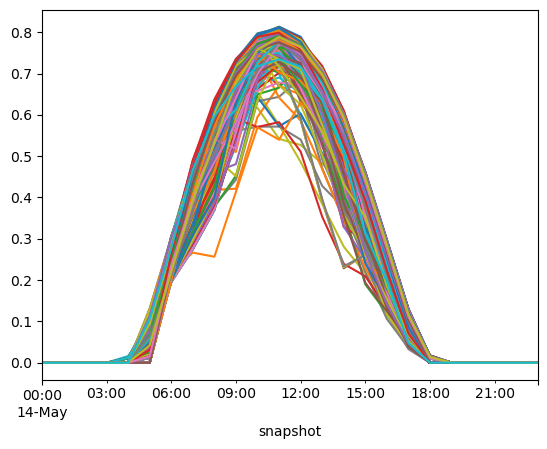

In [ ]:
n.generators_t.p_max_pu.loc["2025-05-14":"2025-05-14", 
                            "DE0 0 0 solar":"DE0 99 0 solar"].plot(legend=False)

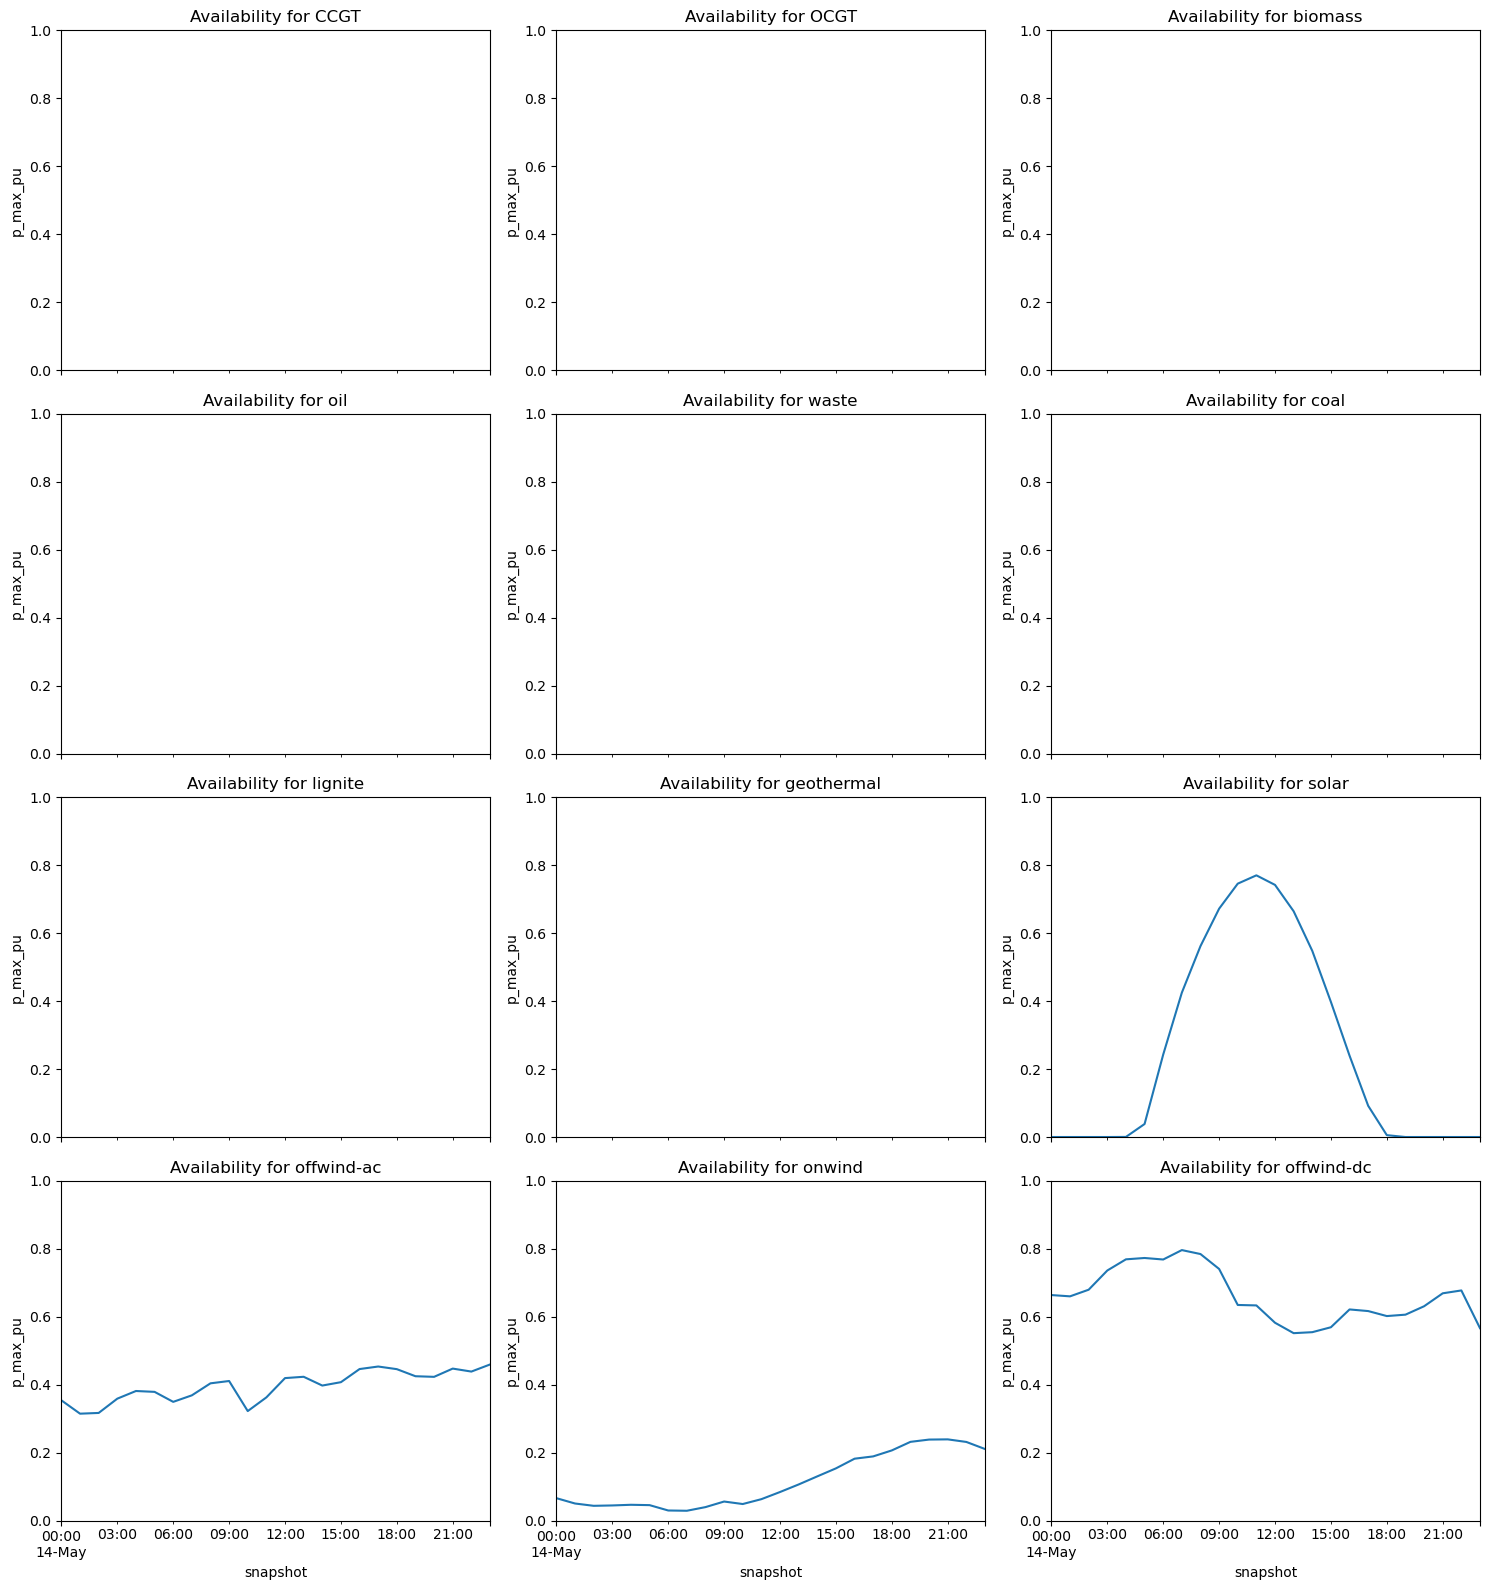

In [356]:
# Get all unique carriers
carriers = n.generators.carrier.unique()

# Create a figure with subplots for each carrier
# Adjust the number of columns and figure size as needed
n_carriers = len(carriers)
n_cols = 3
n_rows = (n_carriers + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4), sharex=True)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, carrier in enumerate(carriers):
    ax = axes[i]
    
    # Find all generators for the current carrier
    gens_for_carrier = n.generators.index[n.generators.carrier == carrier]
    
    # Find the intersection of generators for the carrier and columns in p_max_pu
    common_gens = n.generators_t.p_max_pu.columns.intersection(gens_for_carrier)
    
    # Plot the AVERAGE p_max_pu for these generators
    if not common_gens.empty:
        p_max_pu_carrier = n.generators_t.p_max_pu[common_gens]
        p_max_pu_carrier.mean(axis=1).plot(ax=ax, legend=False)
    
    ax.set_title(f"Availability for {carrier}")
    ax.set_ylabel("p_max_pu")
    ax.set_ylim(0, 1)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Dispatch by carrier type

In [359]:
p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
to_drop = p_by_carrier.max()[p_by_carrier.max() < 1700].index
p_by_carrier.drop(to_drop, axis=1, inplace=True)
p_by_carrier.columns

Index(['biomass', 'coal', 'lignite', 'offwind-ac', 'onwind', 'solar'], dtype='object', name='carrier')

In [367]:
colors = {
    "biomass": "green",
    "coal": "black",
    "lignite": "brown",
    "offwind-ac": "cyan",
    "onwind": "blue",
    "solar": "yellow",
    "gas": "orange",
    "oil": "gray",
    "ror": "turquoise",
    "geothermal": "red",
    # Add other carriers and their colors as needed
}
# reorder
cols = [
    "lignite",
    "coal",
    "biomass",
    "onwind",
    "offwind-ac",
    "solar",
]
p_by_carrier = p_by_carrier[cols]

Text(0.5, 0, '')

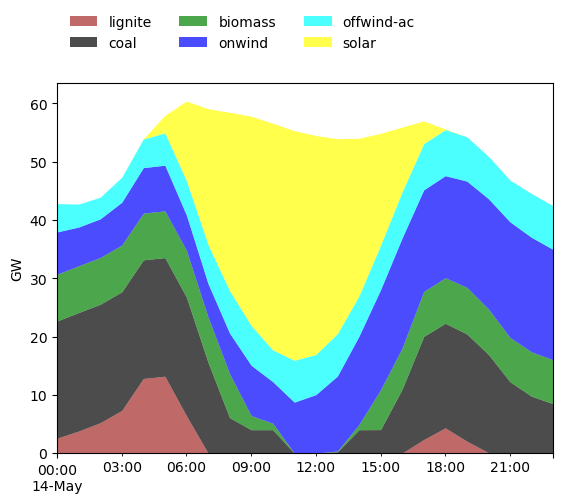

In [368]:
c = [colors[col] for col in p_by_carrier.columns]
fig, ax = plt.subplots()
p_by_carrier.div(1e3).plot(kind="area", ax=ax, lw=0, color=c, alpha=0.7)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, 1.02, 1, 0.2), frameon=False)
ax.set_ylabel("GW")
ax.set_xlabel("")

### Plot storage time series 

Text(0.5, 0, '')

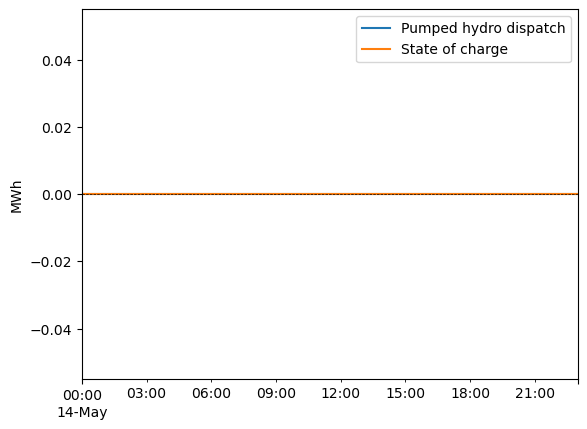

In [369]:
fig, ax = plt.subplots()

p_storage = n.storage_units_t.p.sum(axis=1)
state_of_charge = n.storage_units_t.state_of_charge.sum(axis=1)
p_storage.plot(label="Pumped hydro dispatch", ax=ax)
state_of_charge.plot(label="State of charge", ax=ax)

ax.axhline(0, color="k", lw=0.5, ls="--")
ax.legend()
ax.set_ylabel("MWh")
ax.set_xlabel("")

### Line Loading 

In [373]:
n.snapshots[0]
n.lines.head()

,bus0,bus1,type,x,r,g,b,s_nom,s_nom_mod,s_nom_extendable,...,x_pu,r_pu,g_pu,b_pu,x_pu_eff,r_pu_eff,s_nom_opt,v_nom,i_nom,dc
name,,,,,,,,,,,,,,,,,,,,,
0,DE0 0,DE0 301,Al/St 240/40 4-bundle 380.0,1.207417,0.147246,0.0,0.000142,4379.317262,0.0,True,...,0.000008,1.019709e-06,0.0,0.0,0.000008,1.019709e-06,4379.318168,380.0,2.58,0.0
1,DE0 0,DE0 313,Al/St 240/40 4-bundle 380.0,8.942116,1.090502,0.0,0.000013,491.556019,0.0,True,...,0.000062,7.551952e-06,0.0,0.0,0.000062,7.551952e-06,491.557062,380.0,2.58,0.0
10,DE0 10,DE0 83,Al/St 240/40 4-bundle 380.0,4.656722,0.567893,0.0,0.000328,3396.205223,0.0,True,...,0.000032,3.932777e-06,0.0,0.0,0.000032,3.932777e-06,3396.205504,380.0,2.58,0.0
100,DE0 130,DE0 269,Al/St 240/40 4-bundle 380.0,0.934883,0.114010,0.0,0.000066,3396.205223,0.0,True,...,0.000006,7.895438e-07,0.0,0.0,0.000006,7.895438e-07,3396.206700,380.0,2.58,0.0
101,DE0 131,DE0 246,Al/St 240/40 4-bundle 380.0,16.013971,1.952923,0.0,0.000282,1698.102612,0.0,True,...,0.000111,1.352440e-05,0.0,0.0,0.000111,1.352440e-05,1805.559281,380.0,2.58,0.0


In [383]:
now = n.snapshots[18]
loading = n.lines_t.p0.loc[now] / n.lines.s_nom
loading.describe()

count    666.000000
mean      -0.006925
std        0.411936
min       -3.470228
25%       -0.205081
50%       -0.003108
75%        0.196417
max        3.442529
dtype: float64

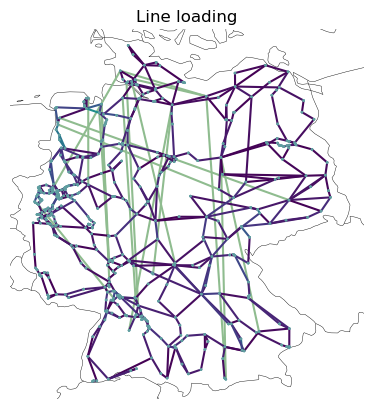

In [392]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.EqualEarth()})
n.plot(
    ax=ax,
    line_color=loading.abs(),
    line_cmap="viridis",
    title="Line loading",
    bus_size=1e-3,
);

### Curtailment
By considering how much power is available and how much is generated, you can see what share is curtailed:

In [384]:
n.generators.head()

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
DE0 0 CCGT,DE0 0,Slack,,31.77900,0.0,True,31.77900,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,31.779008
DE0 0 OCGT,DE0 0,PQ,,26.53169,0.0,True,26.53169,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,26.531708
DE0 0 biomass,DE0 0,PQ,,86.65898,0.0,False,86.65898,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,86.658980
DE0 0 oil,DE0 0,PQ,,33.30020,0.0,False,33.30020,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,33.300200
DE0 0 waste,DE0 0,PQ,,72.92500,0.0,False,72.92500,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,72.925000


In [ ]:
carrier = "onwind"

capacity = n.generators.groupby("carrier").sum().at[carrier, "p_nom"]
p_available = n.generators_t.p_max_pu.multiply(n.generators["p_nom"])
p_available_by_carrier = p_available.T.groupby(n.generators.carrier).sum().T
p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

In [387]:
p_df = pd.DataFrame(
    {
        carrier + " available": p_available_by_carrier[carrier],
        carrier + " dispatched": p_by_carrier[carrier],
        carrier + " curtailed": p_curtailed_by_carrier[carrier],
    }
)

p_df[carrier + " capacity"] = capacity

In [389]:
p_df.loc[p_df["onwind curtailed"] < 0, "onwind curtailed"] = 0

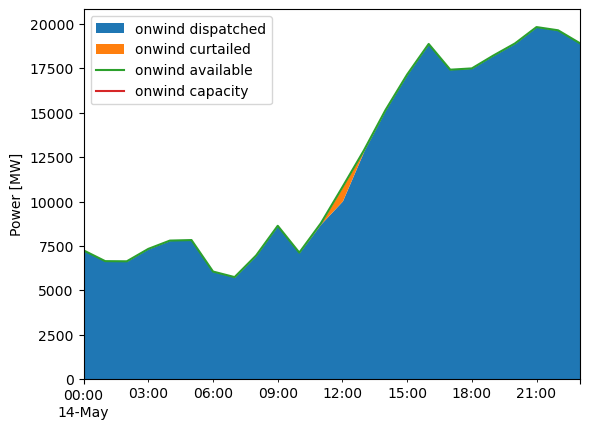

In [391]:
fig, ax = plt.subplots()
p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0)
p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Power [MW]")
#ax.set_ylim([0, 40_000])
ax.legend()